In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

<Axes: ylabel='Count'>

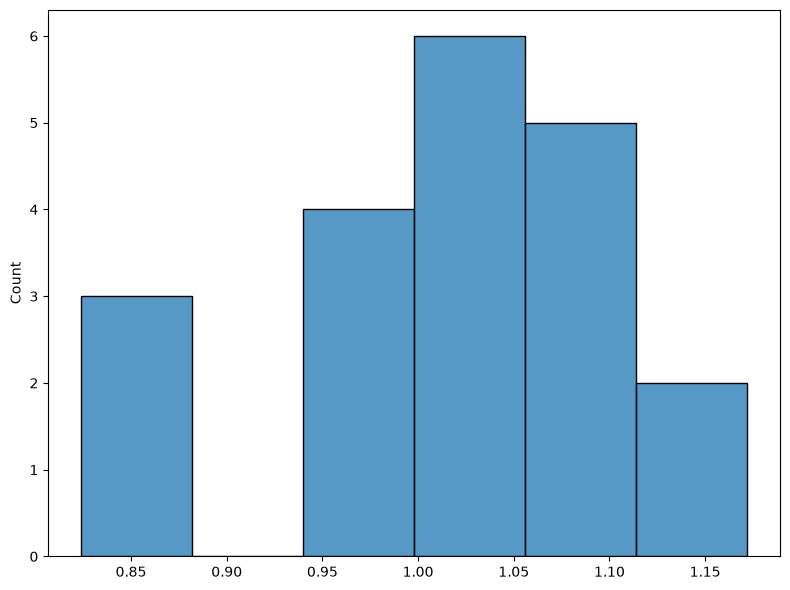

In [17]:
# create a normal distribution
mu, sigma_ = 1, 0.1 # mean and standard deviation
normal_data = np.random.normal(mu,sigma_,20)
prior_mu, prior_sigma = 0.9, 0.5 # mean and standard deviation

plt.figure(
    figsize=(8,6),
    layout = 'tight'
)

sns.histplot(
    data=normal_data
)

In [ ]:
def gaussian_pdf(x:np.array, mu:float, sigma:float, n_samples:int):
    """
    Calculate the probability density function of a Gaussian distribution.
    
    Parameters:
    x : np.array
        The data points for which to calculate the PDF.
    mu : float
        The mean of the Gaussian distribution.
    sigma : float
        The standard deviation of the Gaussian distribution.
    n_samples : int
        The number of samples in the dataset
        
    Returns:
    np.array
        The PDF values for each data point in x.
    """
    exponential = np.exp(
            -(np.sum((x - mu)**2)) / (2 * sigma**2)
            )
    fraction = (
            1 / np.sqrt(2 * np.pi * sigma**2)
            ) ** n_samples
    return fraction * exponential

def gaussian_pdf_point(updated_mean: float, prior_mean: float, prior_sigma: float):
    """
    Density of a single scalar value under N(mean, sigma).
    
    We use this to calculate the prior probability of the mean and sigma.

    """
    fraction = 1 / np.sqrt(2 * np.pi * prior_sigma**2)
    exponential = np.exp(-((updated_mean - prior_mean)**2) / (2 * prior_sigma**2))
    return fraction * exponential


def log_likelihood_calculation(x:np.array, mu:float, sigma:float, n_samples:int):
    """ 
    outputs a list of the loglihood and their derivitives

    Parameters:
    x : np.array
        The data points for which to calculate the PDF.
    mu : float
        The mean of the Gaussian distribution.
    sigma : float
        The standard deviation of the Gaussian distribution.
    n_samples : int
        The number of samples in the dataset
    
    """
    # loop through the samples at the given mu and sigma
    likelihood = gaussian_pdf(x, mu, sigma, n_samples)
    prior = gaussian_pdf_point(mu, prior_mu, prior_sigma)

    log_likelihood = np.log(likelihood) + np.log(prior)
    

    # calculate the derivitives
    mu_prime = 1/sigma**2 * (np.sum(x) - n_samples * mu)
    sigma_prime = (- n_samples / sigma) + (1/sigma**3 * np.sum((x - mu) ** 2))

    # derivitives of the priors
    mu_prime_prior = -(mu - prior_mu) / prior_sigma**2

    # prior gradients
    mu_prime += mu_prime_prior





    return mu_prime, sigma_prime, log_likelihood

def viz_the_history(history:list):
    """
    Show how the function got to its solution

    Parameters:
    x : list
        The changes over iterations to mu and sigma.
    
    """
    df = pd.DataFrame(history)
    fig, axes = plt.subplots(
        3,1,figsize=(10,8)
    )
    # the y labels
    labels = ['Log-Likelihood','Mean','Sigma']

    # loop and visualise!
    for i in range(3):
        sns.lineplot(
            data=df.iloc[:1000],
            x='Iteration',
            y=labels[i],
            ax=axes[i]
        )
    
    # add title
    plt.suptitle(
        "A Visual Representation of MAP",
        fontsize=18,
        fontweight='bold',
        color='grey'
    )

    # adjust the axis labels
    size_and_color = {
        "fontsize":12,
        "fontweight":"bold",
        "color":"grey"
    }

    for ax in axes.flat:
        ax.set_ylabel(ax.get_ylabel(),**size_and_color)
        ax.set_xlabel(ax.get_xlabel(),**size_and_color)

    plt.tight_layout()

def gaussian_MAP_function(x : np.array):
    """
    Manually computes the MLE parameters for a Gaussian distribution
    using gradient ascent on the log-likelihood.

    Steps:
    1. Initialise mu and sigma.
    2. Calculate the Gaussian log-likelihood.
    3. Calculate the Gaussian log-likelihood for the Prior.
    4. Calculate the gradients with respect to mu and sigma.
    5. Update mu and sigma using gradient ascent.
    6. Repeat until convergence.
    7. Visualise the optimisation history.
    """
    # set mu to the first point in the data
    # as we will be changing these over iterations
    # what they begin with does not matter.
    mu = np.min(x)
    sigma = 0.5
    n_samples = len(x)

    # iterate over the dataset to calculate their likelihood
    iterations = 10000
    lr = 0.0001
    history = list()

    for iteration in range(iterations):
        mu_prime, sigma_prime, log_likelihood = log_likelihood_calculation(x,mu,sigma,n_samples)

        # Convergence
        if (
            abs(mu_prime) < 1e-6
            and abs(sigma_prime) < 1e-6
            ):
            break

        # control each parameter
        mu += lr * mu_prime
        sigma += lr * sigma_prime

        
        #save the history
        history.append({
            "Iteration":iteration,
            "Mean":mu,
            "Mean Gradient":mu_prime,
            "Sigma":sigma,
            "Sigma Gradient":sigma_prime,
            "Log-Likelihood":log_likelihood
        })


    viz_the_history(history)

    return mu, sigma


    


Estimated Mean: 1.0145644617917071, Estimated Sigma: 0.08821644349725564


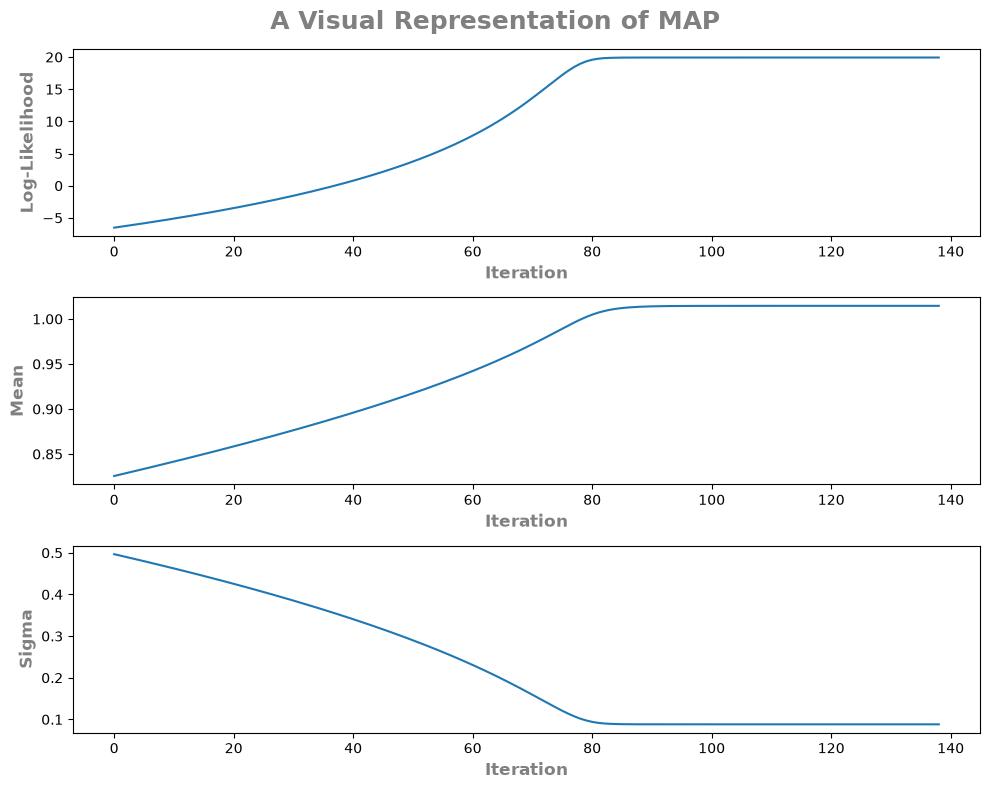

In [24]:
# lets try to use the above function!
est_mu, est_sigma = gaussian_MAP_function(normal_data)

print(f"Estimated Mean: {est_mu}, Estimated Sigma: {est_sigma}")